## **Plantilla**

In [36]:
import pandas as pd

ruta = "https://raw.githubusercontent.com/VillaltaE/netflix_churn/refs/heads/main/netflix_customer_churn.csv"
df = pd.read_csv(ruta)

model_cols = [
    "subscription_type",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day",
    "payment_method"
]

X = df[model_cols]
y = df["churned"]

X.head(), y.value_counts(normalize=True)


(  subscription_type  watch_hours  last_login_days  monthly_fee  \
 0             Basic        14.73               29         8.99   
 1          Standard         0.70               19        13.99   
 2          Standard        16.32               10        13.99   
 3           Premium         4.51               12        17.99   
 4          Standard         1.89               13        13.99   
 
    number_of_profiles  avg_watch_time_per_day payment_method  
 0                   1                    0.49      Gift Card  
 1                   5                    0.03      Gift Card  
 2                   2                    1.48         Crypto  
 3                   2                    0.35         Crypto  
 4                   2                    0.13         Crypto  ,
 churned
 1    0.503
 0    0.497
 Name: proportion, dtype: float64)

## **Importar lo necesario**

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier as RandomForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt



## **Definir columnas por tipo**



In [38]:
categorical_cols = ["subscription_type","payment_method"]
numeric_cols = [
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]


## **Crear el preprocesador**

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


## **Train/Test split (80/20)**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((4000, 7), (1000, 7))

## **Armar el pipeline**

In [41]:
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

## **Entrenar**

In [42]:
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['subscription_type',
                                                   'payment_method']),
                                                 ('num', 'passthrough',
                                                  ['watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day'])])),
                ('model', LogisticRegression(max_iter=1000))])

## **Evaluar**

### Reporte de clasificación

In [43]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.88      0.89       497
           1       0.88      0.91      0.90       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



### Matriz de confusión

In [44]:
print(confusion_matrix(y_test, y_pred))

[[436  61]
 [ 45 458]]


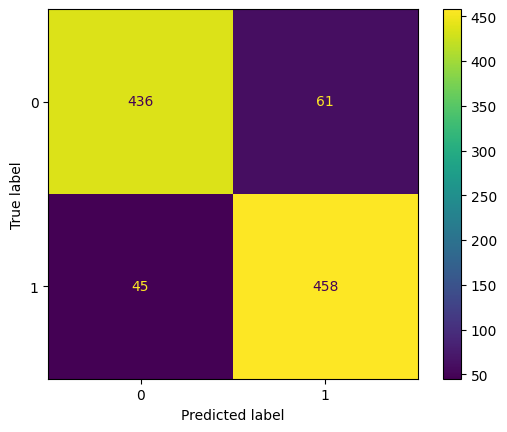

In [45]:
visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
visualizacion.plot();

### Precisión

In [46]:
print(f'La precisión del modelo es :{accuracy_score(y_test, y_pred)}')

La precisión del modelo es :0.894


### Curva ROC

In [47]:
print(roc_curve(y_test, y_pred))

(array([0.        , 0.12273642, 1.        ]), array([0.        , 0.91053678, 1.        ]), array([inf,  1.,  0.]))


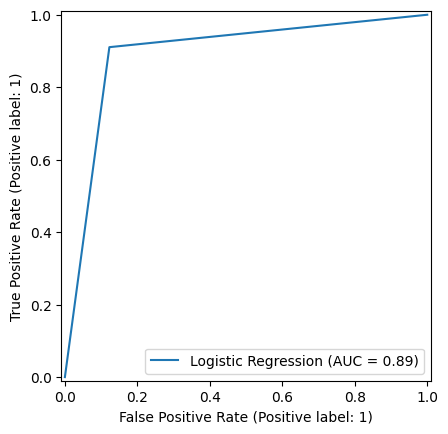

In [48]:
RocCurveDisplay.from_predictions(y_test,y_pred,name='Logistic Regression');

In [49]:
from sklearn.metrics import roc_auc_score

In [69]:
#Gráfico alternativo de la curva ROC
# Generar un predictor sin habilidad
ns_probs = [0 for _ in range(len(y_test))]
# Probabilidades de la regresión logistica
lr_probs = clf.predict_proba(X_test)
# Probabilidad de solo la clase "1"
lr_probs = lr_probs[:, 1]
# Calculo de la métrica auc
ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, y_pred)

print(ns_auc)
print(lr_auc)

# Cáculo de la curva roc
ns_fpr, ns_tpr, t = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, t = roc_curve(y_test, y_pred)




0.5
0.8939001804064945


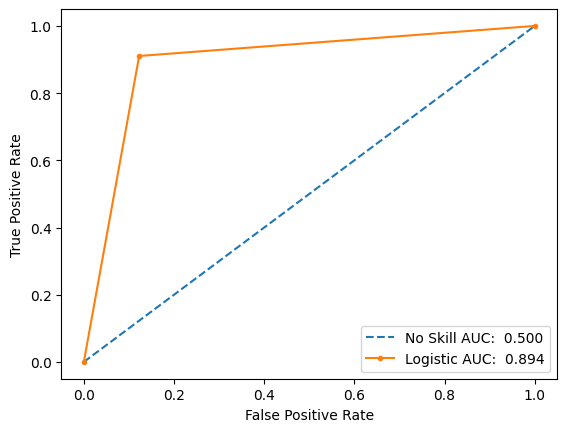

In [70]:
#Gráfico de la curva ROC
plt.plot(ns_fpr, ns_tpr, linestyle='--', label=f'No Skill AUC: {ns_auc: .3f}')
plt.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic AUC: {lr_auc: .3f}')
# Etiquetas de los ejes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Mostrar la leyenda
plt.legend()
# Mostrar el gráfico
plt.show()

### Curva Precisión Sensibilidad

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

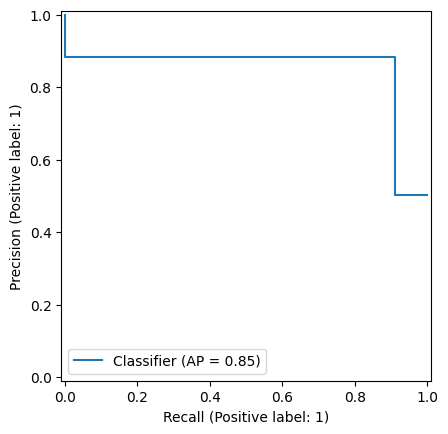

In [ ]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred);

In [ ]:
#Gŕafico alternativo


In [ ]:
from sklearn.metrics import average_precision_score

In [ ]:
print(round(average_precision_score(y_test, y_pred),3))

0.849


### Interpretación de las métricas y gráficos

En el gráfico ROC, observamos que el modelo tiene una excelente capacidad para distinguir entre las dos clases de churn, respaldado por un AUC de 0.89. Esto significa que el modelo es altamente eficaz separando a los clientes que se irán de los que se quedarán.

Otro aspecto crítico es la estabilidad del modelo: como se ve en la curva Precisión vs Sensibilidad (Recall), a medida que aumentamos la sensibilidad para capturar a más clientes en riesgo, la precisión no decae bruscamente, sino que se mantiene constante y en un valor muy alto, cercano al 90%.

En conclusión, el modelo logra un balance óptimo entre precisión y sensibilidad, permitiéndonos identificar al 90% de los desertores con un margen de error mínimo. Este rendimiento global se resume en el Puntaje Promedio de Precisión (AP) de 0.85, lo que garantiza una alta rentabilidad en las acciones de retención.

## **Serializamos el modelo**

In [ ]:
import pickle

with open('modelo.pkl', 'wb') as archivo:
    pickle.dump(clf, archivo)

## **Cargamos el modelo**


In [ ]:
with open('modelo.pkl', 'rb') as archivo:
    clf = pickle.load(archivo)

## **Probabilidades / API**

In [ ]:
#Probabilidad de que un cliente se vaya (churn=1)
y_proba = clf.predict_proba(X_test)[:, 1]
y_proba[:10]


array([3.80590617e-05, 9.82798657e-01, 8.60439089e-01, 9.88645567e-01,
       9.91690587e-01, 9.85568817e-01, 9.37351830e-01, 9.99969087e-01,
       3.83984624e-01, 8.23470085e-01])

In [ ]:
def predict_cliente(input_dict):
    """
    Documentación de la función
    """
    #df con las caracteristicas del cliente a predecir
    df_input = pd.DataFrame([input_dict])
    #Guardamos la variable id
    id = int(df_input['customer_id'].iloc[0])
    #luego la eliminamos del df para que no intervenga en el modelo
    datos_input = df_input.drop(columns=['customer_id'])
    #corremos el modelo
    proba = clf.predict_proba(datos_input)[0, 1]
    pred = "Va a cancelar" if proba >= 0.5 else "Va a continuar"
    # la salida: id junto con la predicción del modelo
    return {
        "customer_id": id,
        "prediction": pred,
        "probability": round(float(proba), 3)
    }
    
    

## **Función de predicción**

### Probar con un cliente / Manual

In [ ]:
cliente_ejemplo = {
    "customer_id": 10,
    "subscription_type": "Standard",
    "watch_hours": 3,
    "last_login_days": 1,
    "monthly_fee": 16,
    "number_of_profiles": 2,
    "avg_watch_time_per_day": 0.35,
    "payment_method": "Debit Card"

}

print(f'La predicción del modelo es:{predict_cliente(cliente_ejemplo)}')


La predicción del modelo es:{'customer_id': 10, 'prediction': 'Va a continuar', 'probability': 0.064}
